In [ ]:
import os
import shutil
import subprocess

# Ensure triton can find a C compiler (needed for SAM3 mask post-processing kernel)
if not shutil.which("gcc"):
    subprocess.run(["apt-get", "install", "-y", "gcc", "build-essential"],
                   check=False, capture_output=True)
gcc_path = shutil.which("gcc") or "/usr/bin/gcc"
os.environ["CC"] = gcc_path
print(f"CC set to: {gcc_path}")

import time
import json
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Using device:", device)


In [ ]:
#using_colab = False

#if using_colab:
import torch
import torchvision
print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA is available:", torch.cuda.is_available())
import sys
#%{sys.executable} -m pip install opencv-python matplotlib scikit-learn
#%{sys.executable} -m pip install 'git+https://github.com/facebookresearch/sam3.git'

Found existing installation: opencv-python 4.9.0.80
Uninstalling opencv-python-4.9.0.80:
  Successfully uninstalled opencv-python-4.9.0.80
Found existing installation: opencv-python-headless 4.13.0.92
Uninstalling opencv-python-headless-4.13.0.92:
  Successfully uninstalled opencv-python-headless-4.13.0.92
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
  Using cached opencv_python-4.9.0.80-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (20 kB)
Using cached opencv_python-4.9.0.80-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (62.2 MB)
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
PyTorch version: 2.9.1+cu128
Torchvision version: 0.24.1+cu128
CUDA is available: True
Note: you may need to restart the kernel to use updated packages.
  Cloning https://github.com/facebookresearch/sam3.git to /t

In [ ]:
import os
os.environ["HF_TOKEN"] = "hf_PUNE_TOKENUL_TAU_AICI"
from huggingface_hub import whoami
print(whoami())

/home/cbojan/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'type': 'user', 'id': '688e03f0c38838e091f48f92', 'name': 'carinabojan', 'fullname': 'Carina Bojan', 'isPro': False, 'avatarUrl': '/avatars/d5c650eb9c3fa489a855ffb8b26f08b3.svg', 'orgs': [], 'auth': {'type': 'access_token', 'accessToken': {'displayName': 'LocallySAM3', 'role': 'fineGrained', 'createdAt': '2026-01-12T19:16:13.051Z', 'fineGrained': {'canReadGatedRepos': False, 'global': [], 'scoped': [{'entity': {'_id': '690d80fc9f252aa897a1dc6d', 'type': 'model', 'name': 'facebook/sam3'}, 'permissions': ['repo.content.read']}, {'entity': {'_id': '688e03f0c38838e091f48f92', 'type': 'user', 'name': 'carinabojan'}, 'permissions': ['repo.content.read']}]}}}}


In [ ]:
from huggingface_hub import hf_hub_download

hf_hub_download(
    repo_id="facebook/sam3",
    filename="config.json",
)

'/home/cbojan/.cache/huggingface/hub/models--facebook--sam3/snapshots/3c879f39826c281e95690f02c7821c4de09afae7/config.json'

In [ ]:
import sam3
from sam3 import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor

/home/cbojan/miniconda3/lib/python3.13/site-packages/sam3/model_builder.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [ ]:
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True


sam3_root = os.path.dirname(sam3.__file__)
bpe_path = f"{sam3_root}/assets/bpe_simple_vocab_16e6.txt.gz"

sam_model = build_sam3_image_model(
    bpe_path=bpe_path,
    enable_inst_interactivity=True
)

processor = Sam3Processor(sam_model)

print("SAM loaded.")

SAM loaded.


In [ ]:
np.random.seed(3)

def show_mask(mask, ax, random_color=False, borders = True):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask = mask.astype(np.uint8)
    mask_image =  mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    if borders:
        import cv2
        contours, _ = cv2.findContours(mask,cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE) 
        # Try to smooth contours
        contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
        mask_image = cv2.drawContours(mask_image, contours, -1, (1, 1, 1, 0.5), thickness=2) 
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)   

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0, 0, 0, 0), lw=2))    

def show_masks(image, masks, scores, point_coords=None, box_coords=None, input_labels=None, borders=True):
    for i, (mask, score) in enumerate(zip(masks, scores)):
        plt.figure(figsize=(10, 10))
        plt.imshow(image)
        show_mask(mask, plt.gca(), borders=borders)
        if point_coords is not None:
            assert input_labels is not None
            show_points(point_coords, input_labels, plt.gca())
        if box_coords is not None:
            # boxes
            show_box(box_coords, plt.gca())
        if len(scores) > 1:
            plt.title(f"Mask {i+1}, Score: {score:.3f}", fontsize=18)
        plt.axis('off')
        plt.show()

In [ ]:
def compute_iou(pred_mask, gt_mask):
    pred = pred_mask.astype(bool)
    gt = gt_mask.astype(bool)
    intersection = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    if union == 0:
        return 0.0
    return float(intersection / union)


def run_sam_inference(sam_model, processor, image_np, point_coords, point_labels):
    """
    Run SAM3 on a single image with given point prompts.
    Returns the best mask (numpy bool array, shape HÃ—W).
    """
    inference_state = processor.set_image(image_np)

    point_coords = np.asarray(point_coords, dtype=np.float32)[None, ...]  # (1, N, 2)
    point_labels = np.asarray(point_labels, dtype=np.int32)[None, ...]    # (1, N)

    sam_masks, scores, _ = sam_model.predict_inst(
        inference_state,
        point_coords=point_coords,
        point_labels=point_labels,
        multimask_output=True  # Changed to False for single mask
    )

    sam_mask = sam_masks[np.argmax(scores)]

    return sam_mask

In [ ]:
CONFIG = {
    "batch_size": 8,
    "num_epochs": 20,
    "learning_rate": 1e-4,     
    "num_pos_points": 1,
    "num_neg_points": 0,

    "image_size": 512,

    "policy_std_start": 0.20,
    "policy_std_end": 0.08,

    "max_grad_norm": 1.0,

    "weight_decay": 2e-4,

    "dropout": 0.20,

    "debug_every_n_batches": 40,
    "vis_every_n_batches": 40,

    # "sep_loss_weight": 0.3,
    "num_rollouts": 3,
    "backbone_lr": 1e-5,
    "entropy_weight": 0.05,
    
    "temperature": 10,
}

NUM_POINTS   = CONFIG["num_pos_points"] + CONFIG.get("num_neg_points", 0)
POINT_LABELS = np.array(
    [1] * CONFIG["num_pos_points"] + [0] * CONFIG.get("num_neg_points", 0),
    dtype=np.int32
)

print("CONFIG:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")
print(f"NUM_POINTS  : {NUM_POINTS}")
print(f"POINT_LABELS: {POINT_LABELS}")


In [ ]:
# DEBUG HELPER FUNCTIONS

def debug_visualize_masks(image_np, sam_mask, gt_mask, point_coords, point_labels, iou,
                          epoch, batch_idx, vis_dir, phase="train"):
    """
    Visualize the predicted SAM mask vs ground truth mask.
    point_labels: array of 1 (positive) and 0 (negative) — positive shown green, negative red.
    """
    fig, axes = plt.subplots(1, 4, figsize=(24, 6))

    # Panel 1: Original image with predicted points
    axes[0].imshow(image_np)
    for (x, y), lbl in zip(point_coords, point_labels):
        color = 'lime' if lbl == 1 else 'red'
        axes[0].scatter(x, y, c=color, s=200, marker='*', edgecolors='black', linewidths=1.5, zorder=5)
    axes[0].set_title(f"Image + Points (green=pos, red=neg)\nEp {epoch+1}, Batch {batch_idx} ({phase})")
    axes[0].axis("off")

    # Panel 2: SAM predicted mask
    axes[1].imshow(image_np)
    mask_overlay = np.zeros((*sam_mask.shape, 4))
    mask_overlay[..., 2] = 1.0
    mask_overlay[..., 3] = sam_mask.astype(float) * 0.5
    axes[1].imshow(mask_overlay)
    axes[1].set_title(f"SAM Mask\nIoU = {iou:.4f}")
    axes[1].axis("off")

    # Panel 3: Ground truth mask
    axes[2].imshow(image_np)
    gt_overlay = np.zeros((*gt_mask.shape, 4))
    gt_overlay[..., 1] = 1.0
    gt_overlay[..., 3] = gt_mask.astype(float) * 0.5
    axes[2].imshow(gt_overlay)
    axes[2].set_title("Ground Truth Mask")
    axes[2].axis("off")

    # Panel 4: Error analysis overlay
    pred_bool = sam_mask.astype(bool)
    gt_bool = gt_mask.astype(bool)
    error_overlay = np.zeros((*sam_mask.shape, 3), dtype=np.float32)
    error_overlay[pred_bool & gt_bool]   = [0, 1, 0]
    error_overlay[pred_bool & ~gt_bool]  = [1, 0, 0]
    error_overlay[~pred_bool & gt_bool]  = [1, 1, 0]
    img_float = image_np.astype(np.float32) / 255.0 if image_np.max() > 1 else image_np.astype(np.float32)
    blended = np.clip(img_float * 0.5 + error_overlay * 0.5, 0, 1)
    axes[3].imshow(blended)
    axes[3].set_title("Error: G=TP, R=FP, Y=FN")
    axes[3].axis("off")

    plt.tight_layout()
    save_path = os.path.join(vis_dir, f"debug_{phase}_epoch{epoch+1}_batch{batch_idx}.png")
    plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"    [DEBUG] Saved visualization: {save_path}")


def debug_check_gradients(model):
    print("    [DEBUG GRADIENTS]")
    for name, param in model.named_parameters():
        if param.grad is not None:
            g = param.grad
            print(f"      {name:40s} | mean={g.mean().item():+.6f} | "
                  f"std={g.std().item():.6f} | max={g.max().item():+.6f} | "
                  f"min={g.min().item():+.6f}")
        else:
            print(f"      {name:40s} | ** NO GRADIENT **")


def debug_check_predictions(mu, epoch, batch_idx):
    pts = mu[0].detach().cpu().float().numpy()
    print(f"    [DEBUG PREDICTIONS] Epoch {epoch+1}, Batch {batch_idx}")
    for i, (x, y) in enumerate(pts):
        lbl = "pos" if i < CONFIG["num_pos_points"] else "neg"
        print(f"      Point {i} ({lbl}): ({x:.4f}, {y:.4f})")


def debug_check_mask_ranges(gt_mask, sam_mask):
    print(f"    [DEBUG MASK RANGES]")
    print(f"      GT  mask: min={gt_mask.min():.4f}, max={gt_mask.max():.4f}, "
          f"dtype={gt_mask.dtype}, shape={gt_mask.shape}")
    print(f"      SAM mask: min={sam_mask.min():.4f}, max={sam_mask.max():.4f}, "
          f"dtype={sam_mask.dtype}, shape={sam_mask.shape}")


def debug_check_param_updates(model, prev_params):
    current_params = {}
    for name, param in model.named_parameters():
        current_params[name] = param.data.clone()
    if prev_params is not None:
        print("    [DEBUG PARAM UPDATES]")
        for name in current_params:
            diff = (current_params[name] - prev_params[name]).abs().mean().item()
            print(f"      {name:40s} | mean_change={diff:.8f}")
    return current_params


In [ ]:
from torchvision import transforms
import albumentations as A
import cv2

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

class CarPromptDatasetSplit(Dataset):
    def __init__(self, split_root, image_size=128, supervision_type="mask", augment=False, blacklist=None):
        assert supervision_type in ["mask", "heatmap"]
        self.supervision_type = supervision_type
        self.image_size = image_size
        self.augment = augment
        self.samples = []

        if augment:
            self.augment_pipeline = A.Compose([
                # --- Spatiale ---
                A.ShiftScaleRotate(
                    shift_limit=0.25,
                    scale_limit=0.25,
                    rotate_limit=20,
                    border_mode=cv2.BORDER_CONSTANT,
                    value=0,
                    mask_value=0,
                    p=0.8,
                ),
                A.RandomResizedCrop(
                    height=image_size,
                    width=image_size,
                    scale=(0.4, 1.0),
                    ratio=(1.0, 1.0),
                    p=0.5,
                ),
                A.HorizontalFlip(p=0.5),
                # --- Color/Intensity ---
                A.ColorJitter(
                    brightness=0.3,
                    contrast=0.3,
                    saturation=0.3,
                    hue=0.1,
                    p=0.3,
                ),
                A.OneOf([
                    A.ISONoise(p=1.0),
                    A.GaussNoise(var_limit=(10.0, 50.0), p=1.0),
                ], p=0.3),
                A.GaussianBlur(blur_limit=(3, 7), p=0.25),
                A.RandomGamma(gamma_limit=(80, 120), p=0.25),
                # --- Ocluzie ---
                A.CoarseDropout(
                    max_holes=8,
                    min_holes=1,
                    max_height=64,
                    min_height=16,
                    max_width=64,
                    min_width=16,
                    fill_value=0,
                    mask_fill_value=0,
                    p=0.3,
                ),
            ])
        else:
            self.augment_pipeline = None

        _blacklist = set(blacklist) if blacklist is not None else set()

        for seq in sorted(os.listdir(split_root)):
            seq_root = os.path.join(split_root, seq)
            images_root = os.path.join(seq_root, "Images")
            labels_root = os.path.join(seq_root, "Labels")
            heatmaps_root = os.path.join(seq_root, "Heatmaps")

            if not os.path.isdir(images_root):
                continue

            for cars_folder in sorted(os.listdir(images_root)):
                img_dir = os.path.join(images_root, cars_folder)
                if not os.path.isdir(img_dir):
                    continue

                if supervision_type == "mask":
                    tgt_dir = os.path.join(labels_root, cars_folder)
                else:
                    tgt_dir = os.path.join(heatmaps_root, cars_folder)

                if not os.path.isdir(tgt_dir):
                    continue

                for fname in sorted(os.listdir(img_dir)):
                    if not fname.startswith("car_"):
                        continue

                    img_path = os.path.join(img_dir, fname)

                    if img_path in _blacklist:
                        continue

                    if supervision_type == "mask":
                        tgt_path = os.path.join(tgt_dir, fname)
                    else:
                        tgt_path = os.path.join(tgt_dir, fname.replace(".png", ".npy"))

                    if os.path.exists(tgt_path):
                        self.samples.append((img_path, tgt_path))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, tgt_path = self.samples[idx]
        img = Image.open(img_path).convert("RGB")
        img = img.resize((self.image_size, self.image_size), resample=Image.BILINEAR)
        img = np.array(img, dtype=np.uint8)

        if self.supervision_type == "mask":
            target = Image.open(tgt_path).convert("L")
            target = target.resize((self.image_size, self.image_size), resample=Image.NEAREST)
            target = np.array(target, dtype=np.uint8)

        if self.augment_pipeline is not None:
            augmented = self.augment_pipeline(image=img, mask=target)
            img = augmented["image"]
            target = augmented["mask"]

        img_arr = img.copy()  # uint8, INAINTE de normalizare — pentru SAM si debug

        img = img.astype(np.float32) / 255.0
        img = torch.from_numpy(img).permute(2, 0, 1).float()
        img = (img - IMAGENET_MEAN) / IMAGENET_STD

        if self.supervision_type == "mask":
            target = target.astype(np.float32) / 255.0
        else:
            target = np.load(tgt_path).astype(np.float32)
        target = torch.from_numpy(target).unsqueeze(0).float()
        return img, target, img_path, img_arr


In [ ]:
class CarRGBTestDatasetSplit(Dataset):
    def __init__(self, split_root, image_size=128):
        self.images = []
        self.image_size = image_size

        for seq in sorted(os.listdir(split_root)):
            seq_root = os.path.join(split_root, seq)
            images_root = os.path.join(seq_root, "Images")

            if not os.path.isdir(images_root):
                continue

            for cars_folder in sorted(os.listdir(images_root)):
                img_dir = os.path.join(images_root, cars_folder)
                if not os.path.isdir(img_dir):
                    continue

                for fname in sorted(os.listdir(img_dir)):
                    if fname.startswith("car_") and fname.endswith(".png"):
                        self.images.append(os.path.join(img_dir, fname))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        img = Image.open(img_path).convert("RGB")
        img = img.resize((self.image_size, self.image_size), resample=Image.BILINEAR)
        img = np.array(img, dtype=np.float32) / 255.0
        img = torch.from_numpy(img).permute(2, 0, 1).float()
        img = (img - IMAGENET_MEAN) / IMAGENET_STD  # ResNet101 BN calibrated on ImageNet stats
        return img, img_path


In [ ]:
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

BASE     = "/data/New_Dataset_Cars_Extended"

train_dataset = CarPromptDatasetSplit(
    os.path.join(BASE, "train"),
    image_size=CONFIG["image_size"],
    supervision_type="mask",
    augment=True
)

valid_dataset = CarPromptDatasetSplit(
    os.path.join(BASE, "valid"),
    image_size=CONFIG["image_size"],
    supervision_type="mask",
    augment=True
)

test_dataset = CarRGBTestDatasetSplit(
    os.path.join(BASE, "test"),
    image_size=CONFIG["image_size"]
)

print("Train:", len(train_dataset))
print("Valid:", len(valid_dataset))
print("Test :", len(test_dataset))

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=0
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=0
)

print("Train loader batches:", len(train_loader))
print("Valid loader batches:", len(valid_loader))


In [ ]:
import glob as _glob

_base_train = "/data/New_Dataset_Cars_Extended/train/seq10/Images/CarsFromimage000000"
PROBE_PATHS_TRAIN = sorted([
    p for p in _glob.glob(os.path.join(_base_train, "car_*.png"))
    if int(os.path.splitext(os.path.basename(p))[0].split("_")[1]) <= 13
])

_base_valid = "/data/New_Dataset_Cars_Extended/valid/seq10/Images/CarsFromimage000000"
PROBE_PATHS_VALID = sorted(_glob.glob(os.path.join(_base_valid, "car_*.png")))

print(f"Train probe images : {len(PROBE_PATHS_TRAIN)}")
for p in PROBE_PATHS_TRAIN:
    print(f"  {os.path.basename(p)}")
print(f"Valid probe images : {len(PROBE_PATHS_VALID)}")
for p in PROBE_PATHS_VALID:
    print(f"  {os.path.basename(p)}")


In [ ]:
import torchvision.models as models
from torch.utils.checkpoint import checkpoint

class PromptCNN(nn.Module):
    def __init__(self, k=2, dropout=0.35, freeze_backbone=True, num_pos=1, temperature=10):
        super().__init__()
        self.k = k
        self.num_pos = num_pos
        self.temperature = temperature
        self._frozen_modules = []

        backbone = models.resnet101(weights=models.ResNet101_Weights.IMAGENET1K_V1)

        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=1, padding=3, bias=False)
        self.conv1.weight.data = backbone.conv1.weight.data.clone()
        self.bn1  = backbone.bn1
        self.relu = backbone.relu

        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4

        if freeze_backbone:
            for m in [self.conv1, self.bn1, self.layer1, self.layer2,
                      self.layer3, self.layer4]:
                self._freeze(m)

        # normal_(std=1e-3): sparge simetria intre cele k capete
        # Fara z-score: logits initiali ~ N(0, 0.045) cu activari backbone ~1
        # → T=10 → max logit ~1.85 → softmax aproape uniform → start la (0.5, 0.5) cu gradient maxim
        # Pe masura ce weights cresc, heatmap-ul devine mai peaked progresiv
        self.heatmap_conv = nn.Conv2d(2048, k, kernel_size=1)
        nn.init.normal_(self.heatmap_conv.weight, std=1e-3)
        nn.init.zeros_(self.heatmap_conv.bias)

    def _freeze(self, module):
        for p in module.parameters():
            p.requires_grad = False
        self._frozen_modules.append(module)

    def _unfreeze(self, module):
        for p in module.parameters():
            p.requires_grad = True
        if module in self._frozen_modules:
            self._frozen_modules.remove(module)

    def print_frozen_status(self):
        for name, module in [("conv1", self.conv1), ("bn1", self.bn1),
                              ("layer1", self.layer1), ("layer2", self.layer2),
                              ("layer3", self.layer3), ("layer4", self.layer4),
                              ("heatmap_conv", self.heatmap_conv)]:
            frozen = module in self._frozen_modules
            n_train = sum(p.requires_grad for p in module.parameters())
            n_total = sum(1 for _ in module.parameters())
            print(f"  {name:15s}: {'FROZEN' if frozen else 'TRAINABLE':9s}  ({n_train}/{n_total} params trainable)")

    def train(self, mode=True):
        super().train(mode)
        for m in self._frozen_modules:
            m.eval()
        return self

    def forward(self, x):
        x  = self.relu(self.bn1(self.conv1(x)))
        x  = self.layer1(x)
        x  = self.layer2(x)
        x  = self.layer3(x)
        f4 = self.layer4(x)           # (B, 2048, H/8, W/8)

        B, _, H, W = f4.shape

        heatmap = self.heatmap_conv(f4)            # (B, k, H, W)
        heatmap = heatmap.view(B, self.k, -1)      # (B, k, H*W)

        # Fara z-score: la init weights~1e-3 si activari backbone~1 → logits~N(0,0.045)
        # T=10 → max logit~1.85 → softmax aproape uniform → predictie initiala (0.5, 0.5)
        # Z-score ar normaliza la N(0,1) indiferent de scale → T=10 → one-hot → gradient≈0
        heatmap = torch.softmax(heatmap * self.temperature, dim=-1)

        heatmap = heatmap.view(B, self.k, H, W)

        # Grile de coordonate fixe in [0, 1]
        grid_x = torch.linspace(0, 1, W, device=f4.device).view(1, 1, 1, W).expand(B, self.k, H, W)
        grid_y = torch.linspace(0, 1, H, device=f4.device).view(1, 1, H, 1).expand(B, self.k, H, W)

        pred_x = (heatmap * grid_x).sum(dim=[2, 3])  # (B, k)
        pred_y = (heatmap * grid_y).sum(dim=[2, 3])  # (B, k)

        return torch.stack([pred_x, pred_y], dim=-1)  # (B, k, 2) in [0, 1]


In [ ]:
EXP_ROOT = "/data/out/1pos_dropout20"

CKPT_DIR  = os.path.join(EXP_ROOT, "checkpoints")
LOG_DIR   = os.path.join(EXP_ROOT, "logs")
TEST_OUT  = os.path.join(EXP_ROOT, "test_predictions")
VIS_DIR   = os.path.join(EXP_ROOT, "visuals")
PROBE_DIR = os.path.join(EXP_ROOT, "probe_images")

os.makedirs(CKPT_DIR,  exist_ok=True)
os.makedirs(LOG_DIR,   exist_ok=True)
os.makedirs(TEST_OUT,  exist_ok=True)
os.makedirs(VIS_DIR,   exist_ok=True)
os.makedirs(PROBE_DIR, exist_ok=True)

print("Experiment folders ready:", EXP_ROOT)


In [ ]:
import csv
import os
from datetime import datetime

class TrainingLogger:
    """Logs training metrics and model stats to a CSV file."""

    def __init__(self, log_path):
        self.log_path = log_path
        self.headers_written = False

    def log(self, epoch, metrics_dict):
        row = {'epoch': epoch, 'timestamp': datetime.now().isoformat()}
        row.update(metrics_dict)

        file_exists = os.path.exists(self.log_path)

        with open(self.log_path, 'a', newline='') as f:
            writer = csv.DictWriter(f, fieldnames=row.keys())
            if not file_exists or not self.headers_written:
                writer.writeheader()
                self.headers_written = True
            writer.writerow(row)


def count_parameters(model):
    """Returns (trainable, total, percentage)."""
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return trainable, total, 100.0 * trainable / total if total > 0 else 0.0


In [ ]:
def train_simplified_reinforce(model, sam_model, processor, train_loader, valid_loader, epochs):
    model = model.to(device).float()

    optimizer = torch.optim.AdamW([
        {"params": list(model.heatmap_conv.parameters()), "lr": CONFIG["learning_rate"]},
        {"params": list(model.layer3.parameters()),       "lr": CONFIG["backbone_lr"]},
        {"params": list(model.layer4.parameters()),       "lr": CONFIG["backbone_lr"]},
    ], weight_decay=CONFIG["weight_decay"])

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

    image_size  = CONFIG["image_size"]
    std_start   = CONFIG["policy_std_start"]
    std_end     = CONFIG["policy_std_end"]
    debug_every = CONFIG["debug_every_n_batches"]
    vis_every   = CONFIG["vis_every_n_batches"]

    train_iou_history       = []
    val_iou_history         = []
    val_rollout_iou_history = []
    train_loss_history      = []
    lr_history              = []

    mu_std_history    = []
    grad_norm_history = []
    entropy_history   = []
    adv_std_history   = []

    best_val_iou = -1.0
    best_epoch   = -1

    _tmp      = next(iter(train_loader))
    _dbg_img  = _tmp[0][:1].to(device).float()
    _dbg_mask = _tmp[1][0][0].numpy() > 0.5
    _dbg_arr  = _tmp[3][0].numpy()

    logger = TrainingLogger(os.path.join(LOG_DIR, "training_log.csv"))

    print(f"\n{'='*70}")
    print(f"Starting REINFORCE training  ({NUM_POINTS} points: {POINT_LABELS})")
    print(f"  Epochs: {epochs}  |  Batch: {CONFIG['batch_size']}  |  LR: {CONFIG['learning_rate']}  |  T: {CONFIG['temperature']}")
    print(f"{'='*70}\n")

    for epoch in range(epochs):

        policy_std = std_start - (std_start - std_end) * (epoch / max(epochs - 1, 1))
        print(f"\n{'='*70}\nEPOCH {epoch+1}/{epochs}  (policy_std={policy_std:.4f})\n{'='*70}")

        trainable, total, pct = count_parameters(model)

        model.eval()
        with torch.no_grad():
            _mu = model(_dbg_img)
        _pts = _mu[0].cpu().float().clone()
        _pts[:, 0] *= image_size
        _pts[:, 1] *= image_size
        _pt_coords = _pts.numpy().astype(np.float32)
        _sam = run_sam_inference(sam_model, processor, Image.fromarray(_dbg_arr), _pt_coords, POINT_LABELS)
        _sam = np.array(Image.fromarray(_sam.astype(np.uint8)).resize((image_size, image_size), resample=Image.NEAREST))
        _iou = compute_iou(_sam, _dbg_mask)
        debug_visualize_masks(_dbg_arr, _sam, _dbg_mask, _pt_coords, POINT_LABELS, _iou, epoch, 0, VIS_DIR, phase="train_fixed")
        model.train()

        epoch_ious       = []
        epoch_losses     = []
        batch_mu_stds    = []
        batch_grad_norms = []
        batch_entropies  = []
        batch_adv_stds   = []

        train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")

        for batch_idx, (images, masks, paths, pil_imgs) in enumerate(train_bar):
            images = images.to(device).float()
            B = images.size(0)
            is_debug_batch = (batch_idx % debug_every == 0)
            is_vis_batch   = (batch_idx % vis_every   == 0)

            mu = model(images)

            batch_mu_stds.append(mu.detach().std(dim=0).mean().item())

            dist = torch.distributions.Normal(mu, policy_std)
            K    = CONFIG.get("num_rollouts", 3)

            if is_debug_batch:
                debug_check_predictions(mu, epoch, batch_idx)

            all_samples   = []
            all_log_probs = []
            for k in range(K):
                s         = dist.sample()
                s_clamped = torch.clamp(s, 0.0, 1.0)
                all_samples.append(s_clamped)
                all_log_probs.append(dist.log_prob(s_clamped).sum(dim=[1, 2]))

            rollout_ious = [[0.0] * B for _ in range(K)]

            for i in range(B):
                image_pil   = Image.fromarray(pil_imgs[i].numpy())
                image_arr   = np.array(image_pil)
                gt_mask     = masks[i][0].detach().cpu().numpy()

                all_masks_i  = []
                all_coords_i = []

                for k in range(K):
                    pts    = all_samples[k][i].detach().cpu().clone().float()
                    pts[:, 0] *= image_size
                    pts[:, 1] *= image_size
                    coords = pts.numpy().astype(np.float32)
                    s_mask = run_sam_inference(sam_model, processor, image_pil, coords, POINT_LABELS)
                    s_mask = np.array(Image.fromarray(s_mask.astype(np.uint8)).resize((image_size, image_size), resample=Image.NEAREST))
                    sam_iou = compute_iou(s_mask, gt_mask)
                    H_gt, W_gt = gt_mask.shape
                    px = min(max(int(round(coords[0, 0])), 0), W_gt - 1)
                    py = min(max(int(round(coords[0, 1])), 0), H_gt - 1)
                    point_in_mask = float(gt_mask[py, px])
                    rollout_ious[k][i] = sam_iou * point_in_mask
                    all_masks_i.append(s_mask)
                    all_coords_i.append(coords)

                best_k      = int(np.argmax([rollout_ious[k][i] for k in range(K)]))
                best_mask   = all_masks_i[best_k]
                best_coords = all_coords_i[best_k]
                best_iou    = rollout_ious[best_k][i]

                if is_vis_batch and i == 0:
                    debug_visualize_masks(image_arr, best_mask, gt_mask, best_coords, POINT_LABELS,
                                          best_iou, epoch, batch_idx, VIS_DIR, phase="train")

                if i == 0 and is_debug_batch:
                    debug_check_mask_ranges(gt_mask, best_mask)

            rollout_tensor = torch.tensor(rollout_ious, device=device, dtype=torch.float32)
            baseline       = rollout_tensor.mean(dim=0, keepdim=True)
            advantages_kb  = rollout_tensor - baseline
            adv_std_val    = advantages_kb.std().item()
            batch_adv_stds.append(adv_std_val)
            if adv_std_val > 1e-8:
                advantages_kb = advantages_kb / (adv_std_val + 1e-8)

            log_probs_kb   = torch.stack(all_log_probs, dim=0)
            reinforce_loss = -(log_probs_kb * advantages_kb.detach()).mean()

            rewards = rollout_tensor.mean(dim=0).tolist()

            # neg_mu = mu[:, CONFIG["num_pos_points"]:, :]
            # pos_mu = mu[:, :CONFIG["num_pos_points"], :]
            # sep_loss = torch.tensor(0.0, device=device)
            # for n in range(CONFIG.get("num_neg_points", 0)):
            #     for p in range(CONFIG["num_pos_points"]):
            #         sep_dist = torch.norm(neg_mu[:, n] - pos_mu[:, p], dim=1)
            #         sep_loss = sep_loss + torch.clamp(0.25 - sep_dist, min=0.0).mean()
            sep_loss = torch.tensor(0.0, device=device)

            entropy_bonus = dist.entropy().mean()
            batch_entropies.append(entropy_bonus.item())

            total_loss = (
                reinforce_loss
                # + CONFIG["sep_loss_weight"] * sep_loss
                - CONFIG["entropy_weight"]   * entropy_bonus
            )

            if is_debug_batch:
                print(f"    [LOSS] reinforce={reinforce_loss.item():.4f}  ent={entropy_bonus.item():.4f}  total={total_loss.item():.4f}")
                print(f"    [B-SCST K={K}] mean_reward={np.mean(rewards):.4f}  baseline={baseline.mean().item():.4f}  "
                      f"adv_std={adv_std_val:.4f}  mu_std={batch_mu_stds[-1]:.4f}")

            optimizer.zero_grad()
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["max_grad_norm"])

            hc_grad = model.heatmap_conv.weight.grad
            if is_debug_batch:
                rg = model.heatmap_conv.weight.requires_grad
                gv = f"{hc_grad.norm().item():.2e}" if hc_grad is not None else "None"
                print(f"    [GRAD] heatmap_conv requires_grad={rg}  grad_norm={gv}  "
                      f"total_loss.requires_grad={total_loss.requires_grad}")
            # inregistreaza 0.0 explicit cand grad e None (lista goala = grad nu a ajuns la heatmap_conv)
            batch_grad_norms.append(hc_grad.norm().item() if hc_grad is not None else 0.0)

            optimizer.step()

            epoch_ious.extend(rewards)
            epoch_losses.append(total_loss.item())
            train_bar.set_postfix(loss=f"{total_loss.item():.4f}", iou=f"{float(np.mean(rewards)):.3f}")

        train_mean_iou  = float(np.mean(epoch_ious))
        train_mean_loss = float(np.mean(epoch_losses))
        train_iou_history.append(train_mean_iou)
        train_loss_history.append(train_mean_loss)
        lr_history.append(optimizer.param_groups[0]['lr'])

        ep_mu_std    = float(np.mean(batch_mu_stds))
        ep_grad_norm = float(np.mean(batch_grad_norms))
        ep_entropy   = float(np.mean(batch_entropies))  if batch_entropies  else 0.0
        ep_adv_std   = float(np.mean(batch_adv_stds))   if batch_adv_stds   else 0.0
        mu_std_history.append(ep_mu_std)
        grad_norm_history.append(ep_grad_norm)
        entropy_history.append(ep_entropy)
        adv_std_history.append(ep_adv_std)

        # VALIDATION — greedy (mu direct) si rollout (K=1 sample din policy)
        model.eval()
        val_ious         = []
        val_rollout_ious = []
        val_bar = tqdm(valid_loader, desc=f"Epoch {epoch+1}/{epochs} [Valid]")

        with torch.no_grad():
            for batch_idx, (images, masks, paths, pil_imgs) in enumerate(val_bar):
                images       = images.to(device).float()
                B            = images.size(0)
                is_vis_batch = (batch_idx % vis_every == 0)
                mu           = model(images)

                val_dist    = torch.distributions.Normal(mu, policy_std)
                val_samples = torch.clamp(val_dist.sample(), 0.0, 1.0)

                for i in range(B):
                    image_pil = Image.fromarray(pil_imgs[i].numpy())
                    image_arr = np.array(image_pil)
                    gt_mask   = masks[i][0].numpy()

                    # greedy — mu direct
                    pts_px = mu[i].detach().cpu().clone().float()
                    pts_px[:, 0] *= image_size
                    pts_px[:, 1] *= image_size
                    point_coords = pts_px.numpy().astype(np.float32)
                    sam_mask = run_sam_inference(sam_model, processor, image_pil, point_coords, POINT_LABELS)
                    sam_mask_resized = np.array(Image.fromarray(sam_mask.astype(np.uint8)).resize((image_size, image_size), resample=Image.NEAREST))
                    val_iou = compute_iou(sam_mask_resized, gt_mask)
                    val_ious.append(val_iou)

                    # rollout K=1 — acelasi tip de stochasticitate ca la train
                    pts_roll = val_samples[i].detach().cpu().clone().float()
                    pts_roll[:, 0] *= image_size
                    pts_roll[:, 1] *= image_size
                    coords_roll = pts_roll.numpy().astype(np.float32)
                    sam_roll = run_sam_inference(sam_model, processor, image_pil, coords_roll, POINT_LABELS)
                    sam_roll_resized = np.array(Image.fromarray(sam_roll.astype(np.uint8)).resize((image_size, image_size), resample=Image.NEAREST))
                    val_rollout_ious.append(compute_iou(sam_roll_resized, gt_mask))

                    if i == 0 and is_vis_batch:
                        debug_visualize_masks(image_arr, sam_mask_resized, gt_mask, point_coords, POINT_LABELS,
                                              val_iou, epoch, batch_idx, VIS_DIR, phase="valid")

                val_bar.set_postfix(iou=f"{np.mean(val_ious[-B:]):.3f}")

        val_mean_iou         = float(np.mean(val_ious))
        val_mean_rollout_iou = float(np.mean(val_rollout_ious))
        val_iou_history.append(val_mean_iou)
        val_rollout_iou_history.append(val_mean_rollout_iou)

        logger.log(epoch + 1, {
            'train_loss':        train_mean_loss,
            'train_rollout_iou': train_mean_iou,
            'val_iou':           val_mean_iou,
            'val_rollout_iou':   val_mean_rollout_iou,
            'lr':                optimizer.param_groups[0]['lr'],
            'trainable_params':  trainable,
            'total_params':      total,
            'trainable_pct':     pct,
            'policy_std':        policy_std,
            'mu_std':            ep_mu_std,
            'grad_norm':         ep_grad_norm,
            'entropy':           ep_entropy,
            'adv_std':           ep_adv_std,
        })

        scheduler.step()
        print(f"\n{'='*60}")
        print(f"EPOCH {epoch+1}/{epochs} SUMMARY")
        print(f"  Train Loss        : {train_mean_loss:.6f}")
        print(f"  Train Rollout IoU : {train_mean_iou:.4f}  (mean K={K} rollouts — reward signal)")
        print(f"  Val Rollout IoU   : {val_mean_rollout_iou:.4f}  (K=1 sample — comparabil cu train)")
        print(f"  Val Greedy IoU    : {val_mean_iou:.4f}  (mu direct — calitate deployment)")
        print(f"  LR                : {optimizer.param_groups[0]['lr']:.8f}")
        print(f"  mu_std            : {ep_mu_std:.4f}   (>0.05 = model diferentiaza imagini)")
        print(f"  grad_norm         : {ep_grad_norm:.2e}  (>1e-4 = gradient util; 0.0 = grad e None)")
        print(f"  entropy           : {ep_entropy:.4f}   (scade odata cu policy_std)")
        print(f"  adv_std           : {ep_adv_std:.4f}   (>0 = semnal REINFORCE activ)")
        print(f"{'='*60}")

        # Probe visualization at epochs 1, 10, num_epochs
        if (epoch + 1) in [1, 10, epochs]:
            model.eval()
            for probe_split, probe_paths in [("train", PROBE_PATHS_TRAIN), ("valid", PROBE_PATHS_VALID)]:
                print(f"  [Probe] Running {probe_split} probe on {len(probe_paths)} images...")
                saved_count = 0
                with torch.no_grad():
                    for probe_path in probe_paths:
                        try:
                            probe_pil = Image.open(probe_path).convert("RGB").resize(
                                (image_size, image_size), resample=Image.BOX
                            )
                            probe_arr = np.array(probe_pil, dtype=np.uint8)
                            probe_t = torch.from_numpy(
                                probe_arr.astype(np.float32) / 255.0
                            ).permute(2, 0, 1).float()
                            probe_t = (probe_t - IMAGENET_MEAN.cpu()) / IMAGENET_STD.cpu()
                            probe_t = probe_t.unsqueeze(0).to(device)

                            mu_probe = model(probe_t)
                            pts = mu_probe[0].cpu().float().clone()
                            pts[:, 0] *= image_size
                            pts[:, 1] *= image_size
                            coords = pts.numpy().astype(np.float32)

                            sam_mask = run_sam_inference(sam_model, processor, probe_pil, coords, POINT_LABELS)
                            sam_mask_r = np.array(
                                Image.fromarray(sam_mask.astype(np.uint8)).resize(
                                    (image_size, image_size), resample=Image.NEAREST
                                )
                            )
                            gt_path = probe_path.replace("/Images/", "/Labels/")
                            gt_arr = np.array(
                                Image.open(gt_path).convert("L").resize(
                                    (image_size, image_size), resample=Image.NEAREST
                                )
                            )
                            gt_mask_probe = (gt_arr > 127)
                            iou_probe = compute_iou(sam_mask_r, gt_mask_probe)
                            fname = os.path.splitext(os.path.basename(probe_path))[0]
                            debug_visualize_masks(
                                probe_arr, sam_mask_r, gt_mask_probe, coords, POINT_LABELS,
                                iou_probe, epoch + 1, 0, PROBE_DIR,
                                phase=f"{probe_split}_ep{epoch+1:02d}_{fname}"
                            )
                            saved_count += 1
                        except Exception as e:
                            print(f"  [Probe] ERROR on {os.path.basename(probe_path)}: {e}")
                print(f"  [Probe] Saved {saved_count}/{len(probe_paths)} {probe_split} probes for epoch {epoch+1}")
            model.train()

        if val_mean_iou > best_val_iou:
            best_val_iou = val_mean_iou
            best_epoch   = epoch + 1
            torch.save({
                'model_state_dict': model.state_dict(),
                'config': CONFIG,
                'num_points': NUM_POINTS,
                'point_labels': POINT_LABELS.tolist(),
                'epoch': epoch + 1,
                'val_iou': val_mean_iou,
            }, os.path.join(CKPT_DIR, "best_model.pth"))
            print("  Saved best model")

        torch.save({
            'model_state_dict': model.state_dict(),
            'config': CONFIG,
            'num_points': NUM_POINTS,
            'point_labels': POINT_LABELS.tolist(),
            'epoch': epoch + 1,
            'val_iou': val_mean_iou,
        }, os.path.join(CKPT_DIR, "latest_model.pth"))

    np.save(os.path.join(LOG_DIR, "train_loss.npy"),       np.array(train_loss_history))
    np.save(os.path.join(LOG_DIR, "lr_history.npy"),       np.array(lr_history))
    np.save(os.path.join(LOG_DIR, "train_iou.npy"),        np.array(train_iou_history))
    np.save(os.path.join(LOG_DIR, "val_iou.npy"),          np.array(val_iou_history))
    np.save(os.path.join(LOG_DIR, "val_rollout_iou.npy"),  np.array(val_rollout_iou_history))
    np.save(os.path.join(LOG_DIR, "debug_mu_std.npy"),     np.array(mu_std_history))
    np.save(os.path.join(LOG_DIR, "debug_grad_norm.npy"),  np.array(grad_norm_history))
    np.save(os.path.join(LOG_DIR, "debug_entropy.npy"),    np.array(entropy_history))
    np.save(os.path.join(LOG_DIR, "debug_adv_std.npy"),    np.array(adv_std_history))

    plot_iou_history(train_iou_history, val_iou_history, val_rollout_iou_history,
                     train_loss_history, mu_std_history, grad_norm_history,
                     entropy_history, adv_std_history)
    print(f"\nTraining finished.  Best epoch: {best_epoch}  Best val IoU: {best_val_iou:.4f}")


def plot_iou_history(train_rollout_ious, val_greedy_ious, val_rollout_ious, train_losses,
                     mu_stds=None, grad_norms=None, entropies=None, adv_stds=None):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    epochs_range = range(1, len(train_rollout_ious) + 1)

    axes[0, 0].plot(epochs_range, train_rollout_ious, 'b-o',  label='Train Rollout IoU (mean K)', markersize=5)
    axes[0, 0].plot(epochs_range, val_rollout_ious,   'g-o',  label='Val Rollout IoU (K=1)',      markersize=5)
    axes[0, 0].plot(epochs_range, val_greedy_ious,    'r--o', label='Val Greedy IoU (deployment)', markersize=5, alpha=0.7)
    axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Mean IoU')
    axes[0, 0].set_title('IoU Over Training')
    axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].plot(epochs_range, train_losses, 'g-o', label='Train Loss', markersize=5)
    axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Loss')
    axes[0, 1].set_title('Training Loss'); axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

    if mu_stds is not None and grad_norms is not None:
        axes[1, 0].plot(epochs_range, mu_stds, 'm-o', label='mu_std (diversitate)', markersize=5)
        ax_r = axes[1, 0].twinx()
        ax_r.plot(epochs_range, grad_norms, 'c-o', label='grad_norm heatmap', markersize=5)
        ax_r.set_ylabel('grad_norm', color='c')
        ax_r.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
        axes[1, 0].set_xlabel('Epoch'); axes[1, 0].set_ylabel('mu_std', color='m')
        axes[1, 0].set_title('Gradient & Prediction Diversity')
        lines1, labels1 = axes[1, 0].get_legend_handles_labels()
        lines2, labels2 = ax_r.get_legend_handles_labels()
        axes[1, 0].legend(lines1 + lines2, labels1 + labels2)
        axes[1, 0].grid(True, alpha=0.3)

    if entropies is not None and adv_stds is not None:
        axes[1, 1].plot(epochs_range, entropies, color='orange', marker='o', label='entropy', markersize=5)
        axes[1, 1].plot(epochs_range, adv_stds,  color='brown',  marker='o', label='adv_std', markersize=5)
        axes[1, 1].set_xlabel('Epoch'); axes[1, 1].set_ylabel('Value')
        axes[1, 1].set_title('Entropy & Advantage Std')
        axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(LOG_DIR, "training_curves.png"), dpi=150, bbox_inches='tight')
    plt.show(); plt.close()
    print(f"Saved training curves to {LOG_DIR}/training_curves.png")


In [ ]:
import json
import csv

def run_validation_debug(model, valid_loader, sam_model, processor, epoch_label, save_root):
    model.eval()
    image_size = CONFIG["image_size"]
    out_dir   = os.path.join(save_root, f"debug_{epoch_label}")
    worst_dir = os.path.join(out_dir, "worst_10")
    os.makedirs(out_dir, exist_ok=True)
    os.makedirs(worst_dir, exist_ok=True)
    records = []
    with torch.no_grad():
        bar = tqdm(valid_loader, desc=f"[{epoch_label}] inference")
        for images, masks, paths, pil_imgs in bar:
            images = images.to(device).float()
            B = images.size(0)
            mu = model(images)
            for i in range(B):
                image_pil = Image.fromarray(pil_imgs[i].numpy())  # resized to image_size, no aug on val
                image_arr = np.array(image_pil)
                pts_px = mu[i].detach().cpu().clone().float()
                pts_px[:, 0] *= image_size
                pts_px[:, 1] *= image_size
                point_coords = pts_px.numpy().astype(np.float32)
                gt_mask = (masks[i][0].numpy() > 0.5)
                sam_mask = run_sam_inference(sam_model, processor, image_pil, point_coords, POINT_LABELS)
                sam_mask_resized = np.array(Image.fromarray(sam_mask.astype(np.uint8)).resize((image_size, image_size), resample=Image.NEAREST))
                iou = compute_iou(sam_mask_resized, gt_mask)
                img_path = paths[i]
                parts = img_path.replace("\\", "/").split("/")
                try:
                    img_idx     = parts.index("Images")
                    seq_name    = parts[img_idx - 1]
                    cars_folder = parts[img_idx + 1]
                    fname       = os.path.splitext(parts[-1])[0]
                    unique_name = f"{seq_name}__{cars_folder}__{fname}"
                except (ValueError, IndexError):
                    unique_name = os.path.splitext(os.path.basename(img_path))[0]
                records.append({
                    "img_path": img_path,
                    "unique_name": unique_name,
                    "iou": float(iou),
                    "point_coords": point_coords.tolist()
                })
            bar.set_postfix(iou=f"{np.mean([r['iou'] for r in records[-B:]]):.3f}")

    mean_iou = float(np.mean([r["iou"] for r in records]))
    records_sorted = sorted(records, key=lambda r: r["iou"])

    print()
    print(f"[{epoch_label}]  N={len(records)}  Mean IoU={mean_iou:.4f}")
    print(f"[{epoch_label}]  Worst 10:")
    for k, r in enumerate(records_sorted[:10]):
        print(f"    #{k+1:2d}  IoU={r['iou']:.4f}  {r['unique_name']}")

    json_path = os.path.join(out_dir, "iou_per_image.json")
    with open(json_path, "w") as f:
        json.dump([
            {"index": k, "rank": rank + 1, "name": r["unique_name"],
             "img_path": r["img_path"], "iou": round(r["iou"], 6)}
            for k, (rank, r) in enumerate(
                sorted(enumerate(records), key=lambda x: x[1]["iou"])
            )
        ], f, indent=2)
    print(f"[{epoch_label}]  Saved: {json_path}")

    print(f"[{epoch_label}]  Generating worst-10 visualizations...")
    for rank, rec in enumerate(records_sorted[:10]):
        img_path = rec["img_path"]
        point_coords = np.array(rec["point_coords"], dtype=np.float32)
        img_pil = Image.open(img_path).convert("RGB").resize((image_size, image_size), resample=Image.BOX)
        image_arr = np.array(img_pil, dtype=np.uint8)
        sam_mask = run_sam_inference(sam_model, processor, img_pil, point_coords, POINT_LABELS)
        sam_mask_resized = np.array(Image.fromarray(sam_mask.astype(np.uint8)).resize((image_size, image_size), resample=Image.NEAREST))
        gt_arr = np.array(Image.open(img_path.replace("/Images/", "/Labels/")).convert("L").resize((image_size, image_size), resample=Image.NEAREST))
        gt_mask = (gt_arr > 127)
        iou = compute_iou(sam_mask_resized, gt_mask)
        prefix = os.path.join(worst_dir, f"rank{rank+1:02d}_iou{iou:.4f}_{rec['unique_name']}")
        Image.fromarray(image_arr).save(prefix + "_image.png")
        Image.fromarray((sam_mask_resized * 255).astype(np.uint8)).save(prefix + "_pred_mask.png")
        Image.fromarray((gt_mask.astype(np.uint8) * 255)).save(prefix + "_gt_mask.png")
        np.savetxt(prefix + "_points.txt", point_coords, fmt="%.2f", header="x  y")
        debug_visualize_masks(image_arr, sam_mask_resized, gt_mask, point_coords, POINT_LABELS,
                              iou, epoch=0, batch_idx=rank, vis_dir=worst_dir,
                              phase=f"{epoch_label}_rank{rank+1:02d}")
    print(f"[{epoch_label}]  Saved to: {worst_dir}")
    print()
    return records


def compare_validation_epochs(records_a, records_b, label_a="epoch_00", label_b="epoch_final", save_dir=None):
    dict_a = {r["img_path"]: r["iou"] for r in records_a}
    dict_b = {r["img_path"]: r["iou"] for r in records_b}
    common_paths = set(dict_a) & set(dict_b)

    if len(common_paths) == 0:
        print("  [Warning] No matching paths — falling back to index-based matching")
        n = min(len(records_a), len(records_b))
        pairs = [(records_a[i]["img_path"], records_a[i]["iou"], records_b[i]["iou"]) for i in range(n)]
    else:
        pairs = [(p, dict_a[p], dict_b[p]) for p in sorted(common_paths)]

    deltas = [(p, iou_a, iou_b, iou_b - iou_a) for p, iou_a, iou_b in pairs]
    deltas_sorted = sorted(deltas, key=lambda x: x[3])

    mean_a    = float(np.mean([iou_a for _, iou_a, _, _ in deltas]))
    mean_b    = float(np.mean([iou_b for _, _, iou_b, _ in deltas]))
    total     = len(deltas)
    improved  = sum(1 for *_, d in deltas if d >  1e-4)
    degraded  = sum(1 for *_, d in deltas if d < -1e-4)
    unchanged = total - improved - degraded

    print()
    print("=" * 60)
    print(f"  COMPARISON: {label_a} -> {label_b}")
    print(f"  Images compared : {total}")
    print(f"  Mean IoU {label_a}: {mean_a:.4f}")
    print(f"  Mean IoU {label_b}: {mean_b:.4f}")
    print(f"  Mean delta      : {mean_b - mean_a:+.4f}")
    print()
    print(f"  Improved : {improved}  ({100*improved/total:.1f}%)")
    print(f"  Unchanged: {unchanged}  ({100*unchanged/total:.1f}%)")
    print(f"  Degraded : {degraded}  ({100*degraded/total:.1f}%)")
    print()
    print("  Top 10 MOST IMPROVED:")
    for p, iou_a, iou_b, d in sorted(deltas, key=lambda x: -x[3])[:10]:
        print(f"    {d:+.4f}   {iou_a:.4f} -> {iou_b:.4f}   {os.path.basename(p)}")
    print()
    print("  Top 10 MOST DEGRADED:")
    for p, iou_a, iou_b, d in deltas_sorted[:10]:
        print(f"    {d:+.4f}   {iou_a:.4f} -> {iou_b:.4f}   {os.path.basename(p)}")

    out_dir  = save_dir or LOG_DIR
    csv_path = os.path.join(out_dir, f"comparison_{label_a}_vs_{label_b}.csv")
    with open(csv_path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["metric", "value"])
        w.writerow(["label_a", label_a])
        w.writerow(["label_b", label_b])
        w.writerow(["total_images", total])
        w.writerow(["mean_iou_a", f"{mean_a:.6f}"])
        w.writerow(["mean_iou_b", f"{mean_b:.6f}"])
        w.writerow(["mean_delta", f"{mean_b - mean_a:+.6f}"])
        w.writerow(["improved",  improved])
        w.writerow(["improved_pct", f"{100*improved/total:.1f}"])
        w.writerow(["unchanged", unchanged])
        w.writerow(["unchanged_pct", f"{100*unchanged/total:.1f}"])
        w.writerow(["degraded",  degraded])
        w.writerow(["degraded_pct", f"{100*degraded/total:.1f}"])

    json_path = os.path.join(out_dir, f"comparison_{label_a}_vs_{label_b}_per_image.json")
    with open(json_path, "w") as f:
        json.dump([
            {"img_path": p, f"iou_{label_a}": round(iou_a, 6),
             f"iou_{label_b}": round(iou_b, 6),
             "delta": round(d, 6),
             "status": "improved" if d > 1e-4 else ("degraded" if d < -1e-4 else "unchanged")}
            for p, iou_a, iou_b, d in sorted(deltas, key=lambda x: x[0])
        ], f, indent=2)

    print()
    print(f"  Summary CSV -> {csv_path}")
    print(f"  Per-image JSON (with paths) -> {json_path}")

    return deltas


In [ ]:
model = PromptCNN(
    k=NUM_POINTS,
    dropout=CONFIG["dropout"],
    freeze_backbone=True,
    num_pos=CONFIG["num_pos_points"],
    temperature=CONFIG["temperature"],
)

model = model.to(device).float()
model._unfreeze(model.layer3)
model._unfreeze(model.layer4)

print(f"Total parameters:     {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Points: {NUM_POINTS}  Labels: {POINT_LABELS}")
print(f"Temperature: {CONFIG['temperature']}")
print("\nFreeze status:")
model.print_frozen_status()

# ── DIAGNOSTIC GRADIENT ── forward+backward rapid (~5s) ────────────────────
model.train()
_tb = next(iter(train_loader))
_ti = _tb[0][:2].to(device).float()
_tm = _tb[1][:2]
_mu_t = model(_ti)
_ys, _xs = torch.where(_tm[0, 0] > 0.5)
_cx = (_xs.float().mean() / CONFIG['image_size']).item() if len(_xs) > 0 else 0.5
_cy = (_ys.float().mean() / CONFIG['image_size']).item() if len(_ys) > 0 else 0.5
_ct = torch.tensor([[_cx, _cy]], device=device).expand(_mu_t.shape[0], -1)
_cl = F.mse_loss(_mu_t[:, 0, :], _ct)
_cl.backward()
_hcw = model.heatmap_conv.weight.grad
_hcb = model.heatmap_conv.bias.grad
_l4g = list(model.layer4.parameters())[-1].grad
_l3g = list(model.layer3.parameters())[-1].grad
print('── GRADIENT DIAGNOSTIC ────────────────────────────────────────')
print('  heatmap_conv.weight :', 'None <-- BUG' if _hcw is None else f'{_hcw.norm().item():.4e}  OK')
print('  heatmap_conv.bias   :', 'None <-- BUG' if _hcb is None else f'{_hcb.norm().item():.4e}  OK')
print('  layer4 last param   :', 'None' if _l4g is None else f'{_l4g.norm().item():.4e}')
print('  layer3 last param   :', 'None' if _l3g is None else f'{_l3g.norm().item():.4e}')
model.zero_grad()
print('────────────────────────────────────────────────────────────────')

# --- Epoch 0 baseline (untrained model) ---
records_epoch_00 = run_validation_debug(
    model, valid_loader, sam_model, processor,
    epoch_label="epoch_00",
    save_root=VIS_DIR
)

# --- Training ---
train_simplified_reinforce(
    model, sam_model, processor,
    train_loader, valid_loader,
    epochs=CONFIG["num_epochs"]
)

# --- Post-training snapshot ---
final_label = f"epoch_{CONFIG['num_epochs']:02d}"
records_epoch_final = run_validation_debug(
    model, valid_loader, sam_model, processor,
    epoch_label=final_label,
    save_root=VIS_DIR
)

# --- Comparison ---
deltas = compare_validation_epochs(
    records_epoch_00, records_epoch_final,
    label_a="epoch_00", label_b=final_label
)


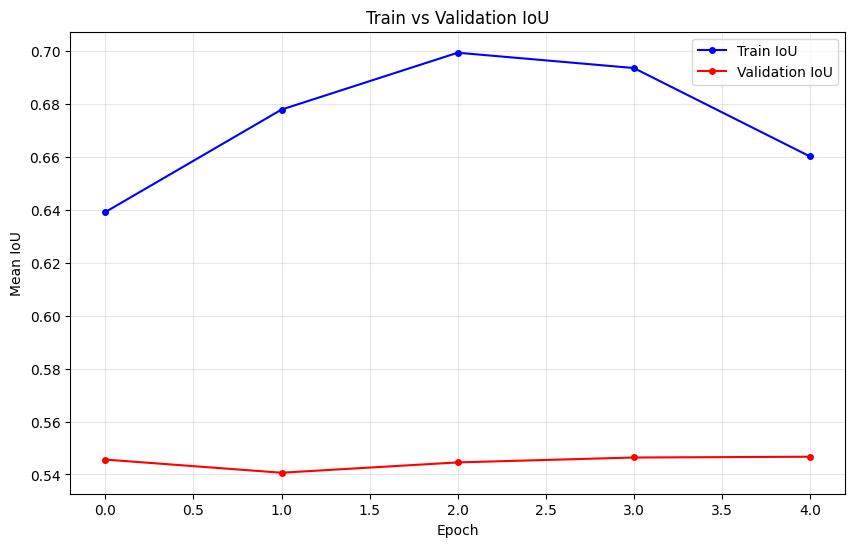

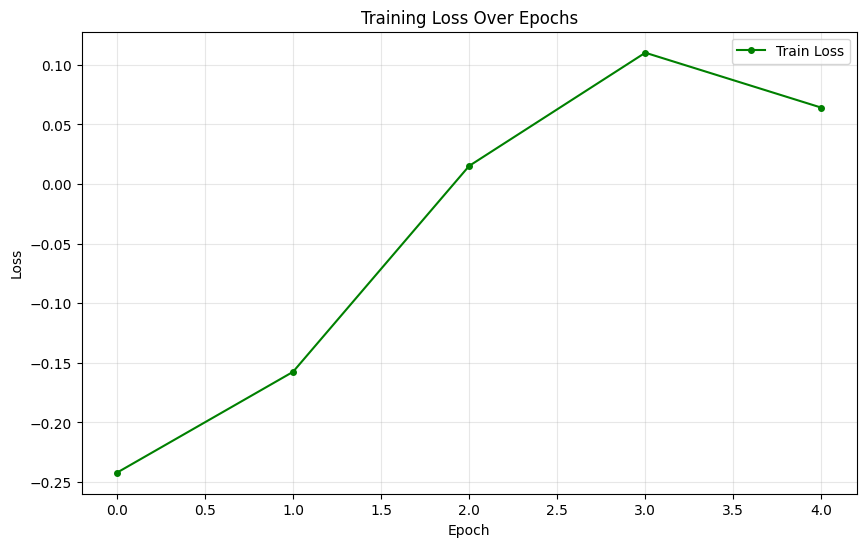

In [ ]:
plt.figure(figsize=(10, 6))
train_ious = np.load(os.path.join(LOG_DIR, "train_iou.npy"))
val_ious = np.load(os.path.join(LOG_DIR, "val_iou.npy"))
plt.plot(train_ious, 'b-o', label="Train IoU", markersize=4)
plt.plot(val_ious, 'r-o', label="Validation IoU", markersize=4)
plt.xlabel("Epoch")
plt.ylabel("Mean IoU")
plt.title("Train vs Validation IoU")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(LOG_DIR, "final_iou_plot.png"), dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 6))
train_losses = np.load(os.path.join(LOG_DIR, "train_loss.npy"))
plt.plot(train_losses, 'g-o', label="Train Loss", markersize=4)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Over Epochs")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(LOG_DIR, "final_loss_plot.png"), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
def visualize_prediction(image_np, point_coords, point_labels, sam_mask, save_path):

    plt.figure(figsize=(6,6))
    plt.imshow(image_np)

    mask = sam_mask.astype(np.uint8)
    overlay = np.zeros((mask.shape[0], mask.shape[1], 4))
    overlay[..., 2] = 1.0
    overlay[..., 3] = mask * 0.4
    plt.imshow(overlay)

    for (x, y), lbl in zip(point_coords, point_labels):
        color = 'lime' if lbl == 1 else 'red'
        plt.scatter(x, y, c=color, s=150, marker='*', edgecolors='white', linewidths=1.5)

    plt.axis("off")
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    plt.close()

In [ ]:
_ckpt = torch.load(
    os.path.join(CKPT_DIR, "best_model.pth"),
    map_location=device
)
# Suporta atat formatul nou (dict cu metadata) cat si cel vechi (state_dict direct)
if isinstance(_ckpt, dict) and 'model_state_dict' in _ckpt:
    model.load_state_dict(_ckpt['model_state_dict'])
    print(f"  Checkpoint: epoch={_ckpt.get('epoch')}, val_iou={_ckpt.get('val_iou', 'N/A'):.4f}")
    print(f"  Config salvat: k={_ckpt['config']['num_pos_points']} pos + {_ckpt['config']['num_neg_points']} neg, dropout={_ckpt['config']['dropout']}")
else:
    model.load_state_dict(_ckpt)
model = model.to(device).float()
model.eval()

print("Loaded BEST model. Running test inference...")

test_ious = []
image_size = CONFIG["image_size"]

with torch.no_grad():
    for idx, (img, img_path) in enumerate(tqdm(test_dataset)):
        img_tensor = img.unsqueeze(0).to(device).float()
        preds = model(img_tensor).float()[0].cpu()

        pts_px = preds.clone().float()
        pts_px[:, 0] *= image_size
        pts_px[:, 1] *= image_size
        point_coords = pts_px.numpy().astype(np.float32)

        image_pil = Image.open(img_path).convert("RGB").resize(
            (image_size, image_size), resample=Image.BOX
        )
        image_arr = np.array(image_pil, dtype=np.uint8)

        sam_mask = run_sam_inference(sam_model, processor, image_pil, point_coords, POINT_LABELS)
        sam_mask_resized = np.array(
            Image.fromarray(sam_mask.astype(np.uint8)).resize(
                (image_size, image_size), resample=Image.NEAREST
            )
        )

        gt_mask_path = img_path.replace("/Images/", "/Labels/")
        gt_arr = np.array(
            Image.open(gt_mask_path).convert("L").resize(
                (image_size, image_size), resample=Image.NEAREST
            )
        )
        gt_mask = (gt_arr > 127)
        iou = compute_iou(sam_mask_resized, gt_mask)
        test_ious.append(iou)

        # Save RGB + mask overlay
        save_name = f"test_{idx:04d}_iou{iou:.3f}.png"
        save_path = os.path.join(TEST_OUT, save_name)
        visualize_prediction(image_arr, point_coords, POINT_LABELS, sam_mask_resized, save_path)

print(f"Test set — N={len(test_ious)}  Mean IoU={np.mean(test_ious):.4f}")
print(f"Overlays saved to: {TEST_OUT}")

In [ ]:
import csv

best_mean = np.mean(test_ious)

csv_path = os.path.join(EXP_ROOT, "eval_iou_results.csv")

with open(csv_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["metric", "value"])
    writer.writerow(["Mean IoU",   f"{best_mean:.4f}"])
    writer.writerow(["Median IoU", f"{np.median(test_ious):.4f}"])
    writer.writerow(["Min IoU",    f"{np.min(test_ious):.4f}"])
    writer.writerow(["Max IoU",    f"{np.max(test_ious):.4f}"])

print(f"Mean IoU (best model): {best_mean:.4f}")
print(f"Results saved to: {csv_path}")